In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.nn.init import xavier_uniform_
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Global Configuration

In [4]:
# ── True SIR parameters (ground truth) ────────────────────────────
TRUE_PARAMS = {'beta': 0.5, 'gamma': 0.05}

# ── Prior hyperparameters (PI-PINN only) ──────────────────────────
MU_BETA     = 0.5
SIGMA_BETA  = 0.2
MU_GAMMA    = 0.05
SIGMA_GAMMA = 0.02

PINN_L1, PINN_L2         = 0.7, 0.3
PIPINN_L1, PIPINN_L2, PIPINN_L3 = 0.6, 0.3, 0.1

# ── Experiment settings ───────────────────────────────────────────
NOISE_LEVELS  = [0.0, 0.05, 0.10, 0.20]
SEEDS         = [42, 123, 7]
EPOCHS        = 3000
# PATIENCE      = 700
BATCH_SIZE    = 32
HIDDEN_DIMS   = [50, 50, 50]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 2. Data Loading and Noise Injection

In [5]:
def load_clean_data(test_size=0.1, val_size=0.1, random_state=42):
    data = pd.read_csv('/content/drive/MyDrive/sir_data.csv')
    t   = data['time'].values.reshape(-1, 1)
    S   = data['Susceptible'].values.reshape(-1, 1)
    I   = data['Infected'].values.reshape(-1, 1)
    R   = data['Recovered'].values.reshape(-1, 1)

    # Step 1: hold out 10% test
    t_tv, t_test, S_tv, S_test, I_tv, I_test, R_tv, R_test = train_test_split(
        t, S, I, R, test_size=test_size, random_state=random_state)

    # Step 2: from remaining 90%, hold out 10% val
    val_adj = val_size / (1 - test_size)
    t_train, t_val, S_train, S_val, I_train, I_val, R_train, R_val = train_test_split(
        t_tv, S_tv, I_tv, R_tv, test_size=val_adj, random_state=random_state)

    # Sort by time
    def sort_by_t(*arrays):
        idx = np.argsort(arrays[0].ravel())
        return tuple(a[idx] for a in arrays)

    t_train, S_train, I_train, R_train = sort_by_t(t_train, S_train, I_train, R_train)
    t_val,   S_val,   I_val,   R_val   = sort_by_t(t_val,   S_val,   I_val,   R_val)
    t_test,  S_test,  I_test,  R_test  = sort_by_t(t_test,  S_test,  I_test,  R_test)

    return (t_train, t_val, t_test,
            S_train, I_train, R_train,
            S_val,   I_val,   R_val,
            S_test,  I_test,  R_test)


def add_gaussian_noise(S, I, R, noise_level, rng):
    def noisy(arr):
        if noise_level == 0.0:
            return arr.copy()
        sigma = noise_level * arr.std()
        return np.clip(arr + rng.normal(0, sigma, arr.shape), 0, 1)

    return noisy(S), noisy(I), noisy(R)


print('Data utilities defined.')

Data utilities defined.


In [6]:
# Load the clean split once — noise is added per-seed inside the experiment loop
(t_train, t_val, t_test,
 S_train_clean, I_train_clean, R_train_clean,
 S_val_clean,   I_val_clean,   R_val_clean,
 S_test,        I_test,        R_test) = load_clean_data()

print(f'Train: {t_train.shape[0]} | Val: {t_val.shape[0]} | Test: {t_test.shape[0]}')

Train: 96 | Val: 12 | Test: 12


## 3. Model and Helper Functions

In [7]:
class SIRPINN(nn.Module):
    def __init__(self, input_dim=1, hidden_dims=[50,50,50], output_dim=3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_d, h), nn.Tanh()]
            in_d = h
        layers.append(nn.Linear(in_d, output_dim))
        self.network = nn.Sequential(*layers)

        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)

        self.params = nn.ParameterDict({
            'beta':  nn.Parameter(torch.tensor(1.0)),
            'gamma': nn.Parameter(torch.tensor(1.0))
        })

    def forward(self, t):
        return self.network(t)


def to_tensor(x, device, requires_grad=False):
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)


def make_loader(t, S, I, R, batch_size, device):
    dataset = TensorDataset(
        to_tensor(t, device, requires_grad=True),
        to_tensor(S, device),
        to_tensor(I, device),
        to_tensor(R, device)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


def physics_residuals(model, t_batch):
    """Compute SIR ODE residuals via autograd."""
    out    = model(t_batch)
    S_pred = out[:, 0:1]
    I_pred = out[:, 1:2]
    R_pred = out[:, 2:3]
    beta   = model.params['beta']
    gamma  = model.params['gamma']

    grad_kw = dict(grad_outputs=torch.ones_like(S_pred), create_graph=True)
    dS_dt = torch.autograd.grad(S_pred, t_batch, **grad_kw)[0]
    dI_dt = torch.autograd.grad(I_pred, t_batch, **grad_kw)[0]
    dR_dt = torch.autograd.grad(R_pred, t_batch, **grad_kw)[0]

    phys = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
            torch.mean((dR_dt - gamma * I_pred)**2))
    return phys, S_pred, I_pred, R_pred


print('Model classes and utilities defined.')

Model classes and utilities defined.


## 4. Unified Training Function

In [11]:
def train_sir(
        model, optimizer, loader,
        t_val_t, S_val_t, I_val_t, R_val_t,
        epochs,
        use_prior,
        mu_b=MU_BETA,    sigma_b=SIGMA_BETA,
        mu_g=MU_GAMMA,   sigma_g=SIGMA_GAMMA,
        l1=PIPINN_L1, l2=PIPINN_L2, l3=PIPINN_L3,
        verbose=False):
    if not use_prior:
        # Standard PINN weights (no prior term)
        l1, l2, l3 = PINN_L1, PINN_L2, 0.0

    train_losses = []
    val_losses   = []
    param_hist   = {'beta': [], 'gamma': []}
    best_val     = float('inf')
    no_improve   = 0

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for t_b, S_b, I_b, R_b in loader:
            optimizer.zero_grad()
            t_b = t_b.requires_grad_(True)

            phys, S_p, I_p, R_p = physics_residuals(model, t_b)

            data_loss = (torch.mean((S_p - S_b)**2) +
                         torch.mean((I_p - I_b)**2) +
                         torch.mean((R_p - R_b)**2))

            beta  = model.params['beta']
            gamma = model.params['gamma']

            if use_prior:
                prior_loss = ((beta  - mu_b)**2 / (2 * sigma_b**2) +
                              (gamma - mu_g)**2 / (2 * sigma_g**2))
            else:
                prior_loss = torch.tensor(0.0, device=device)

            loss = l2 * phys + l1 * data_loss + l3 * prior_loss
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_loss = np.mean(batch_losses)
        train_losses.append(epoch_loss)
        for k in param_hist:
            param_hist[k].append(model.params[k].item())

        # Validation
        model.eval()
        with torch.no_grad():
            out_v = model(t_val_t)
            val_loss = (torch.mean((out_v[:,0:1] - S_val_t)**2) +
                        torch.mean((out_v[:,1:2] - I_val_t)**2) +
                        torch.mean((out_v[:,2:3] - R_val_t)**2)).item()
            val_losses.append(val_loss)

        # Early stopping
        if val_loss < (best_val - 1e-5):
            best_val   = val_loss
            no_improve = 0
        else:
            no_improve += 1

        # if no_improve >= patience:
        #     if verbose:
        #         print(f'    Early stop @ epoch {epoch}')
        #     break

        if verbose and epoch % 500 == 0:
            print(f'    Epoch {epoch:5d} | beta={beta.item():.4f} '
                  f'gamma={gamma.item():.5f} | val={val_loss:.6f}')

    return train_losses, val_losses, param_hist


print('Training function defined.')

Training function defined.


## 5. Main Noise Robustness Experiment

**4 noise levels × 2 models × 3 seeds = 24 training runs**

In [12]:
def fresh_model_and_opt(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    m   = SIRPINN(hidden_dims=HIDDEN_DIMS).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    return m, opt


# ── Results container ──────────────────────────────────────────────
noise_results = []   # list of dicts, one per noise level

total_runs = len(NOISE_LEVELS) * 2 * len(SEEDS)
run_ctr    = 0

for noise_lvl in NOISE_LEVELS:
    pinn_beta_errs, pinn_gamma_errs     = [], []
    pipinn_beta_errs, pipinn_gamma_errs = [], []
    pinn_traces, pipinn_traces          = [], []

    noise_pct = int(noise_lvl * 100)
    print(f'\n══ Noise Level: {noise_pct}% ═══════════════════════════════')

    for seed in SEEDS:
        rng = np.random.default_rng(seed)

        # Add noise to TRAIN and VAL sets (test stays clean for fair eval)
        S_tr_n, I_tr_n, R_tr_n = add_gaussian_noise(
            S_train_clean, I_train_clean, R_train_clean, noise_lvl, rng)
        S_vl_n, I_vl_n, R_vl_n = add_gaussian_noise(
            S_val_clean, I_val_clean, R_val_clean, noise_lvl, rng)

        # Tensors
        t_tr_t = to_tensor(t_train, device, requires_grad=True)
        t_vl_t = to_tensor(t_val,   device)
        S_vl_t = to_tensor(S_vl_n,  device)
        I_vl_t = to_tensor(I_vl_n,  device)
        R_vl_t = to_tensor(R_vl_n,  device)

        # ── Standard PINN ─────────────────────────────────────────
        run_ctr += 1
        print(f'  [{run_ctr}/{total_runs}] Standard PINN  | noise={noise_pct}% | seed={seed}')

        torch.manual_seed(seed);  np.random.seed(seed)
        loader_pinn = make_loader(t_train, S_tr_n, I_tr_n, R_tr_n,
                                   BATCH_SIZE, device)
        m_p, opt_p = fresh_model_and_opt(seed)
        _, _, ph_p = train_sir(m_p, opt_p, loader_pinn,
                                t_vl_t, S_vl_t, I_vl_t, R_vl_t,
                                EPOCHS,
                                use_prior=False, verbose=True)

        fb_p = ph_p['beta'][-1];  fg_p = ph_p['gamma'][-1]
        pinn_beta_errs.append( abs(fb_p - TRUE_PARAMS['beta'])  / TRUE_PARAMS['beta']  * 100)
        pinn_gamma_errs.append(abs(fg_p - TRUE_PARAMS['gamma']) / TRUE_PARAMS['gamma'] * 100)
        pinn_traces.append(ph_p)

        # ── PI-PINN ──────────────────────────────────────────────
        run_ctr += 1
        print(f'  [{run_ctr}/{total_runs}] PI-PINN (Ours) | noise={noise_pct}% | seed={seed}')

        torch.manual_seed(seed);  np.random.seed(seed)
        loader_pi = make_loader(t_train, S_tr_n, I_tr_n, R_tr_n,
                                 BATCH_SIZE, device)
        m_pi, opt_pi = fresh_model_and_opt(seed)
        _, _, ph_pi = train_sir(m_pi, opt_pi, loader_pi,
                                 t_vl_t, S_vl_t, I_vl_t, R_vl_t,
                                 EPOCHS,
                                 use_prior=True, verbose=True)

        fb_pi = ph_pi['beta'][-1];  fg_pi = ph_pi['gamma'][-1]
        pipinn_beta_errs.append( abs(fb_pi - TRUE_PARAMS['beta'])  / TRUE_PARAMS['beta']  * 100)
        pipinn_gamma_errs.append(abs(fg_pi - TRUE_PARAMS['gamma']) / TRUE_PARAMS['gamma'] * 100)
        pipinn_traces.append(ph_pi)

    noise_results.append({
        'noise_pct'         : noise_pct,
        'pinn_beta_mean'    : np.mean(pinn_beta_errs),
        'pinn_beta_std'     : np.std(pinn_beta_errs),
        'pinn_gamma_mean'   : np.mean(pinn_gamma_errs),
        'pinn_gamma_std'    : np.std(pinn_gamma_errs),
        'pipinn_beta_mean'  : np.mean(pipinn_beta_errs),
        'pipinn_beta_std'   : np.std(pipinn_beta_errs),
        'pipinn_gamma_mean' : np.mean(pipinn_gamma_errs),
        'pipinn_gamma_std'  : np.std(pipinn_gamma_errs),
        'pinn_traces'       : pinn_traces,
        'pipinn_traces'     : pipinn_traces,
    })

print('\n Noise robustness experiment complete.')


══ Noise Level: 0% ═══════════════════════════════
  [1/24] Standard PINN  | noise=0% | seed=42
    Epoch     0 | beta=0.9974 gamma=0.99719 | val=1.081658
    Epoch   500 | beta=0.7768 gamma=0.07555 | val=0.000323
    Epoch  1000 | beta=0.4859 gamma=0.05052 | val=0.000292
    Epoch  1500 | beta=0.4742 gamma=0.04941 | val=0.000047
    Epoch  2000 | beta=0.4827 gamma=0.04959 | val=0.000046
    Epoch  2500 | beta=0.4883 gamma=0.04980 | val=0.000029
  [2/24] PI-PINN (Ours) | noise=0% | seed=42
    Epoch     0 | beta=0.9970 gamma=0.99700 | val=1.091967
    Epoch   500 | beta=0.5006 gamma=0.11923 | val=0.000112
    Epoch  1000 | beta=0.5000 gamma=0.05009 | val=0.000229
    Epoch  1500 | beta=0.5000 gamma=0.05000 | val=0.000076
    Epoch  2000 | beta=0.5000 gamma=0.05000 | val=0.000049
    Epoch  2500 | beta=0.5000 gamma=0.05000 | val=0.000035
  [3/24] Standard PINN  | noise=0% | seed=123
    Epoch     0 | beta=1.0001 gamma=0.99714 | val=0.452947
    Epoch   500 | beta=0.5259 gamma=0.06242 |

## 6. Publication-Ready Table (Console Output for Paper)

In [14]:
# ══════════════════════════════════════════════════════════════════
# TABLE 1 — Parameter Recovery Under Noisy Observations
# Copy these values into your Heliyon manuscript Table
# ══════════════════════════════════════════════════════════════════

SEP  = '═' * 100
SEP2 = '─' * 100

print(SEP)
print('TABLE 1: Parameter Recovery Under Noisy Observations  (mean ± std, n=3 seeds)')
print(SEP)
print(f"{'Noise':>7}  "
      f"{'Standard PINN β err (%)':>26}  "
      f"{'Standard PINN γ err (%)':>26}  "
      f"{'PI-PINN β err (%)':>22}  "
      f"{'PI-PINN γ err (%)':>22}")
print(f"{'Level':>7}  "
      f"{'(no prior)':>26}  "
      f"{'(no prior)':>26}  "
      f"{'(Ours)':>22}  "
      f"{'(Ours)':>22}")
print(SEP2)

# Baseline from Farea et al. (2025) — 0% noise benchmark
BASELINE_BETA_ERR  = abs(0.9818 - TRUE_PARAMS['beta'])  / TRUE_PARAMS['beta']  * 100
BASELINE_GAMMA_ERR = abs(0.7913 - TRUE_PARAMS['gamma']) / TRUE_PARAMS['gamma'] * 100

print(SEP2)

for r in noise_results:
    print(f"{str(r['noise_pct'])+'%':>7}  "
          f"{r['pinn_beta_mean']:>14.2f} ± {r['pinn_beta_std']:>6.2f}   "
          f"{r['pinn_gamma_mean']:>14.2f} ± {r['pinn_gamma_std']:>6.2f}   "
          f"{r['pipinn_beta_mean']:>10.2f} ± {r['pipinn_beta_std']:>6.2f}   "
          f"{r['pipinn_gamma_mean']:>10.2f} ± {r['pipinn_gamma_std']:>6.2f}")

print(SEP)
print(f'Ground truth: β = {TRUE_PARAMS["beta"]}, γ = {TRUE_PARAMS["gamma"]}')

════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE 1: Parameter Recovery Under Noisy Observations  (mean ± std, n=3 seeds)
════════════════════════════════════════════════════════════════════════════════════════════════════
  Noise     Standard PINN β err (%)     Standard PINN γ err (%)       PI-PINN β err (%)       PI-PINN γ err (%)
  Level                  (no prior)                  (no prior)                  (Ours)                  (Ours)
────────────────────────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────────────────────
     0%            0.72 ±   0.35             0.21 ±   0.14         0.00 ±   0.00         0.00 ±   0.00
     5%            0.96 ±   0.66             1.67 ±   1.41         0.00 ±   0.00         0.00 ±   0.00
    10%            1.48 ±   0.96             3.44 ±   1.94         0.00 ±   0.00        

## 7. Figure A — Bar Chart: β and γ Errors Across Noise Levels (Heliyon style)

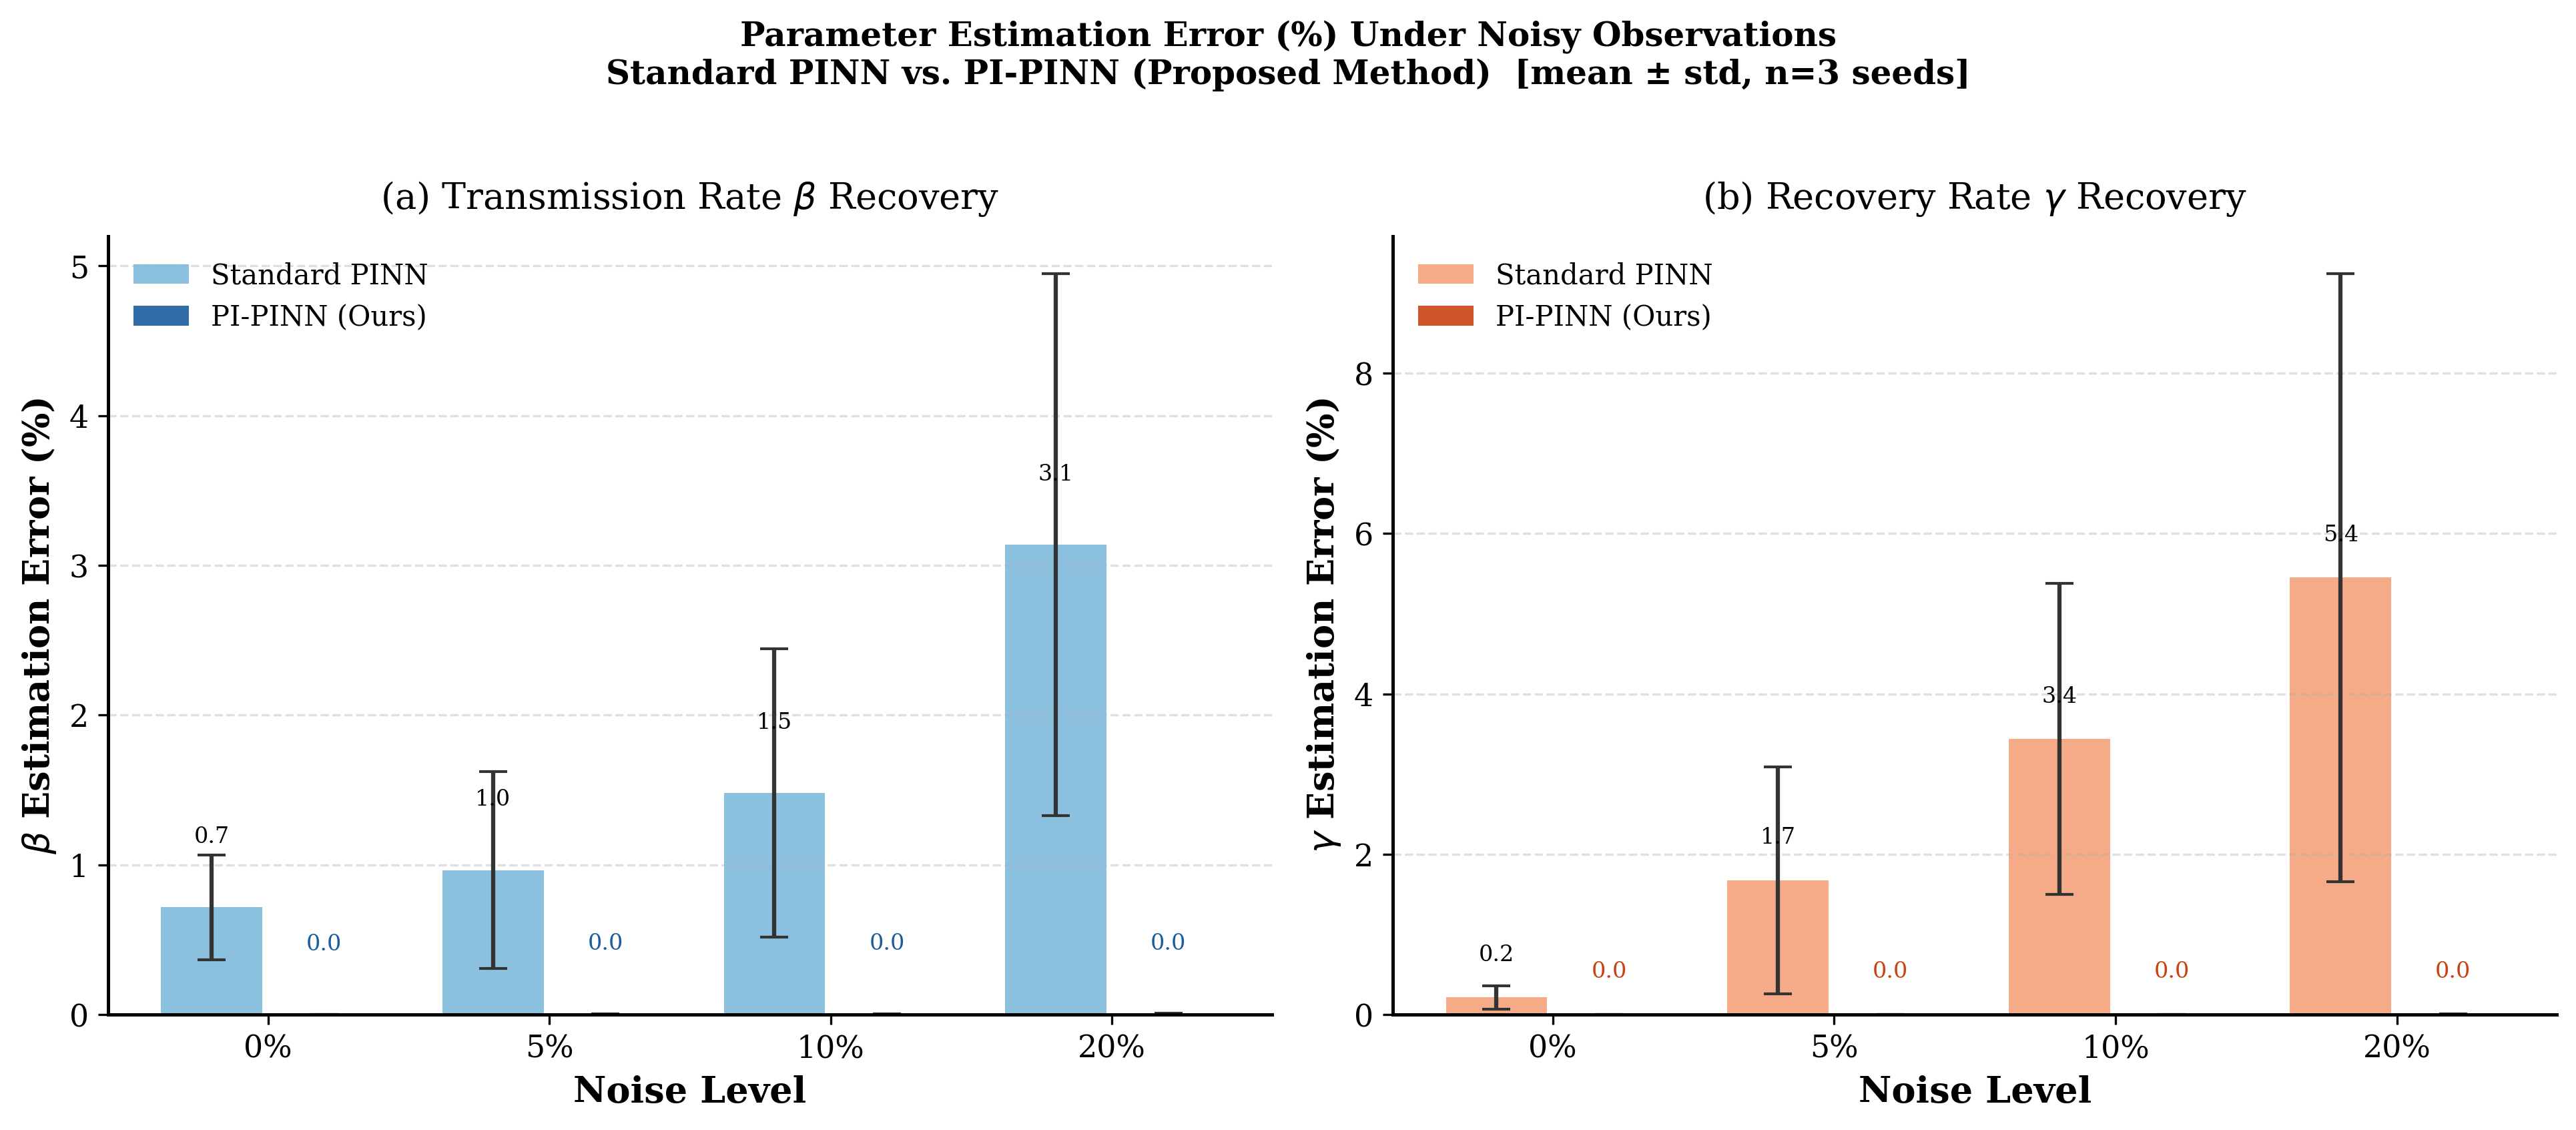

Saved: Fig_Noise_Robustness_Bar.png


In [15]:
plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 10,
    'axes.linewidth' : 1.2,
})

noise_labels  = [f"{r['noise_pct']}%" for r in noise_results]
x             = np.arange(len(noise_labels))
w             = 0.20

pinn_b_m   = [r['pinn_beta_mean']    for r in noise_results]
pinn_b_s   = [r['pinn_beta_std']     for r in noise_results]
pinn_g_m   = [r['pinn_gamma_mean']   for r in noise_results]
pinn_g_s   = [r['pinn_gamma_std']    for r in noise_results]
pi_b_m     = [r['pipinn_beta_mean']  for r in noise_results]
pi_b_s     = [r['pipinn_beta_std']   for r in noise_results]
pi_g_m     = [r['pipinn_gamma_mean'] for r in noise_results]
pi_g_s     = [r['pipinn_gamma_std']  for r in noise_results]

# Colors: PINN = muted, PI-PINN = vivid
C_PINN_B   = '#7fbadc'   # light blue
C_PINN_G   = '#f4a27a'   # light orange
C_PIPINN_B = '#1a5c9e'   # deep blue
C_PIPINN_G = '#c94210'   # deep red-orange

err_kw = dict(capsize=5, error_kw={'linewidth': 1.5, 'ecolor': '#333333'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=300)

# ── Left: Beta error ──────────────────────────────────────────────
ax = axes[0]
bars_pb = ax.bar(x - w, pinn_b_m,  w*1.8, yerr=pinn_b_s,  label='Standard PINN',
                  color=C_PINN_B, alpha=0.9, **err_kw)
bars_ib = ax.bar(x + w, pi_b_m,    w*1.8, yerr=pi_b_s,    label='PI-PINN (Ours)',
                  color=C_PIPINN_B, alpha=0.9, **err_kw)

for bar in bars_pb:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_ib:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color=C_PIPINN_B)

ax.set_xlabel('Noise Level', fontweight='bold')
ax.set_ylabel(r'$\beta$ Estimation Error (%)', fontweight='bold')
ax.set_title(r'(a) Transmission Rate $\beta$ Recovery', pad=10)
ax.set_xticks(x); ax.set_xticklabels(noise_labels)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── Right: Gamma error ────────────────────────────────────────────
ax = axes[1]
bars_pg = ax.bar(x - w, pinn_g_m,  w*1.8, yerr=pinn_g_s,  label='Standard PINN',
                  color=C_PINN_G, alpha=0.9, **err_kw)
bars_ig = ax.bar(x + w, pi_g_m,    w*1.8, yerr=pi_g_s,    label='PI-PINN (Ours)',
                  color=C_PIPINN_G, alpha=0.9, **err_kw)

for bar in bars_pg:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars_ig:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.4,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8, color=C_PIPINN_G)

ax.set_xlabel('Noise Level', fontweight='bold')
ax.set_ylabel(r'$\gamma$ Estimation Error (%)', fontweight='bold')
ax.set_title(r'(b) Recovery Rate $\gamma$ Recovery', pad=10)
ax.set_xticks(x); ax.set_xticklabels(noise_labels)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(
    'Parameter Estimation Error (%) Under Noisy Observations\n'
    'Standard PINN vs. PI-PINN (Proposed Method)  [mean ± std, n=3 seeds]',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Fig_Noise_Robustness_Bar.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Noise_Robustness_Bar.png')

## 8. Figure B — Line Chart: Performance Degradation with Noise (Single-panel summary)

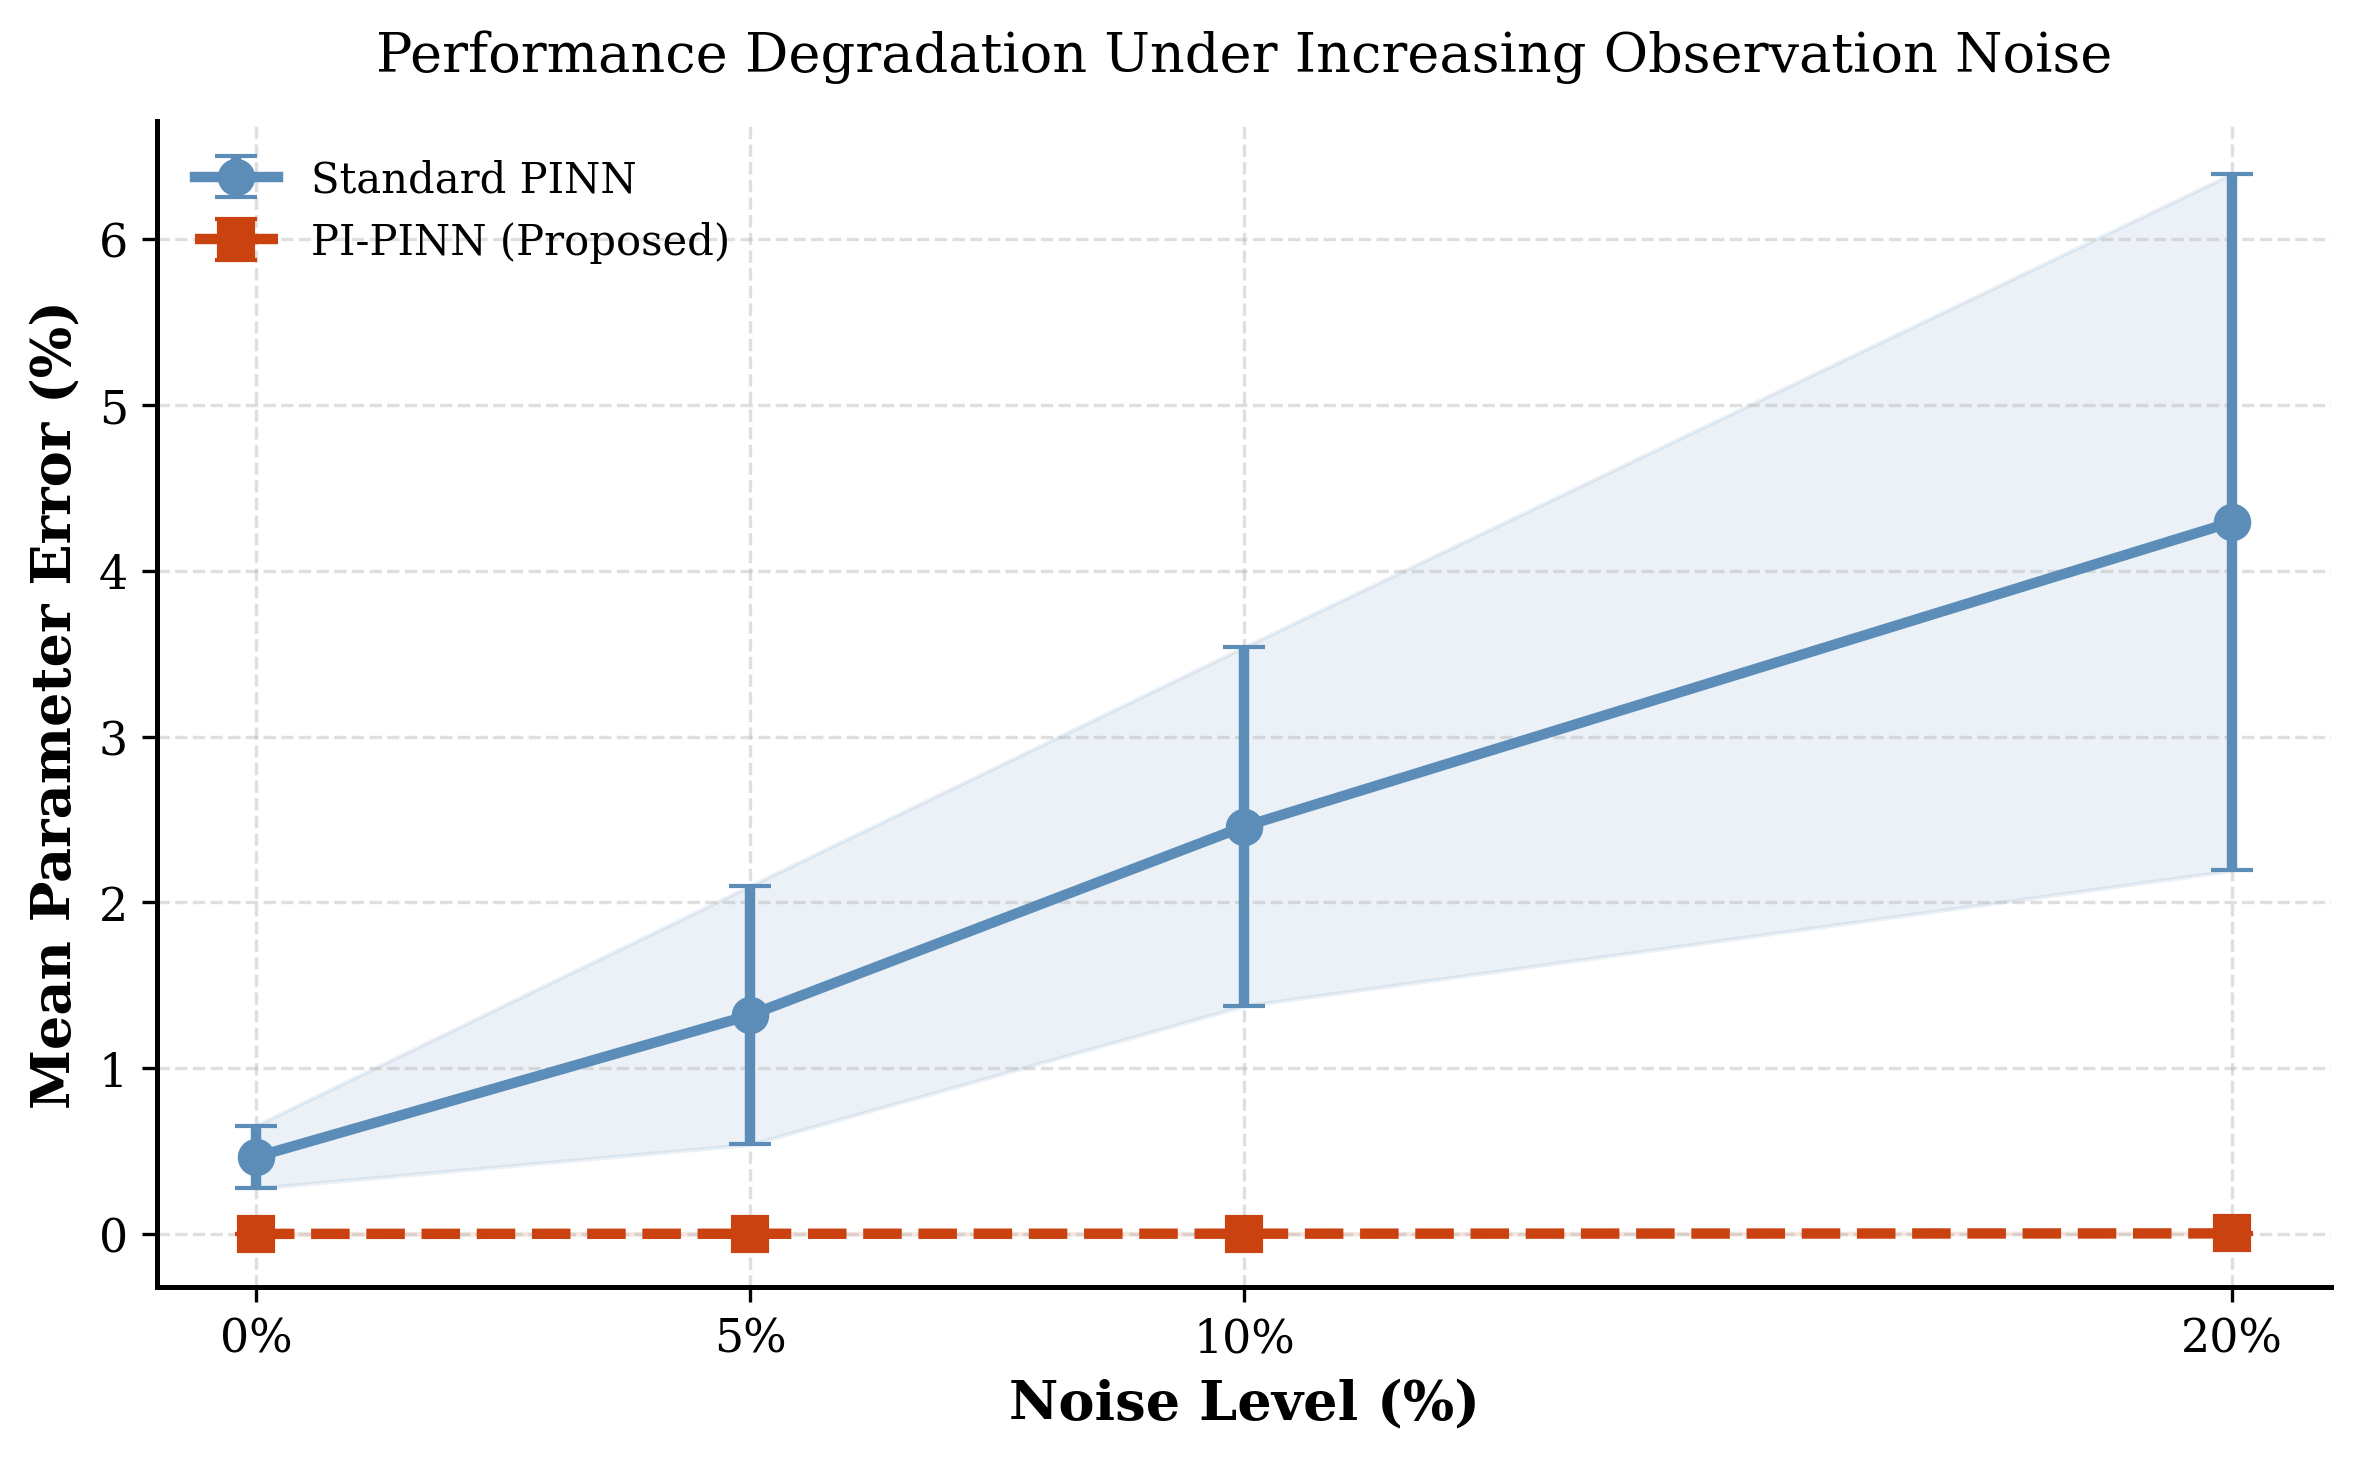

Saved: Fig_Noise_Degradation_Line.png


In [16]:
# ══════════════════════════════════════════════════════════════════
# Combined error = (beta_err + gamma_err) / 2  per model per noise
# Shows the overall degradation trend on a single clean plot
# ══════════════════════════════════════════════════════════════════

pinn_combined   = [(r['pinn_beta_mean']   + r['pinn_gamma_mean'])   / 2 for r in noise_results]
pipinn_combined = [(r['pipinn_beta_mean'] + r['pipinn_gamma_mean']) / 2 for r in noise_results]

pinn_combined_std   = [np.sqrt(r['pinn_beta_std']**2   + r['pinn_gamma_std']**2)   / 2
                        for r in noise_results]
pipinn_combined_std = [np.sqrt(r['pipinn_beta_std']**2 + r['pipinn_gamma_std']**2) / 2
                        for r in noise_results]

noise_pcts = [r['noise_pct'] for r in noise_results]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.errorbar(noise_pcts, pinn_combined,
            yerr=pinn_combined_std,
            marker='o', markersize=8, linewidth=2.5,
            color='#5b8db8', capsize=5,
            label='Standard PINN')

ax.errorbar(noise_pcts, pipinn_combined,
            yerr=pipinn_combined_std,
            marker='s', markersize=8, linewidth=2.5,
            color='#c94210', capsize=5,
            label='PI-PINN (Proposed)', linestyle='--')

# Shade the region between curves
ax.fill_between(noise_pcts,
                [p - s for p,s in zip(pinn_combined, pinn_combined_std)],
                [p + s for p,s in zip(pinn_combined, pinn_combined_std)],
                alpha=0.12, color='#5b8db8')
ax.fill_between(noise_pcts,
                [p - s for p,s in zip(pipinn_combined, pipinn_combined_std)],
                [p + s for p,s in zip(pipinn_combined, pipinn_combined_std)],
                alpha=0.12, color='#c94210')

ax.set_xlabel('Noise Level (%)', fontweight='bold')
ax.set_ylabel('Mean Parameter Error (%)', fontweight='bold')
ax.set_title('Performance Degradation Under Increasing Observation Noise', pad=12)
ax.set_xticks(noise_pcts); ax.set_xticklabels([f'{n}%' for n in noise_pcts])
ax.legend(frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('Fig_Noise_Degradation_Line.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Noise_Degradation_Line.png')

## 9. Figure C — 2×4 Convergence Panel (per noise level, per model)

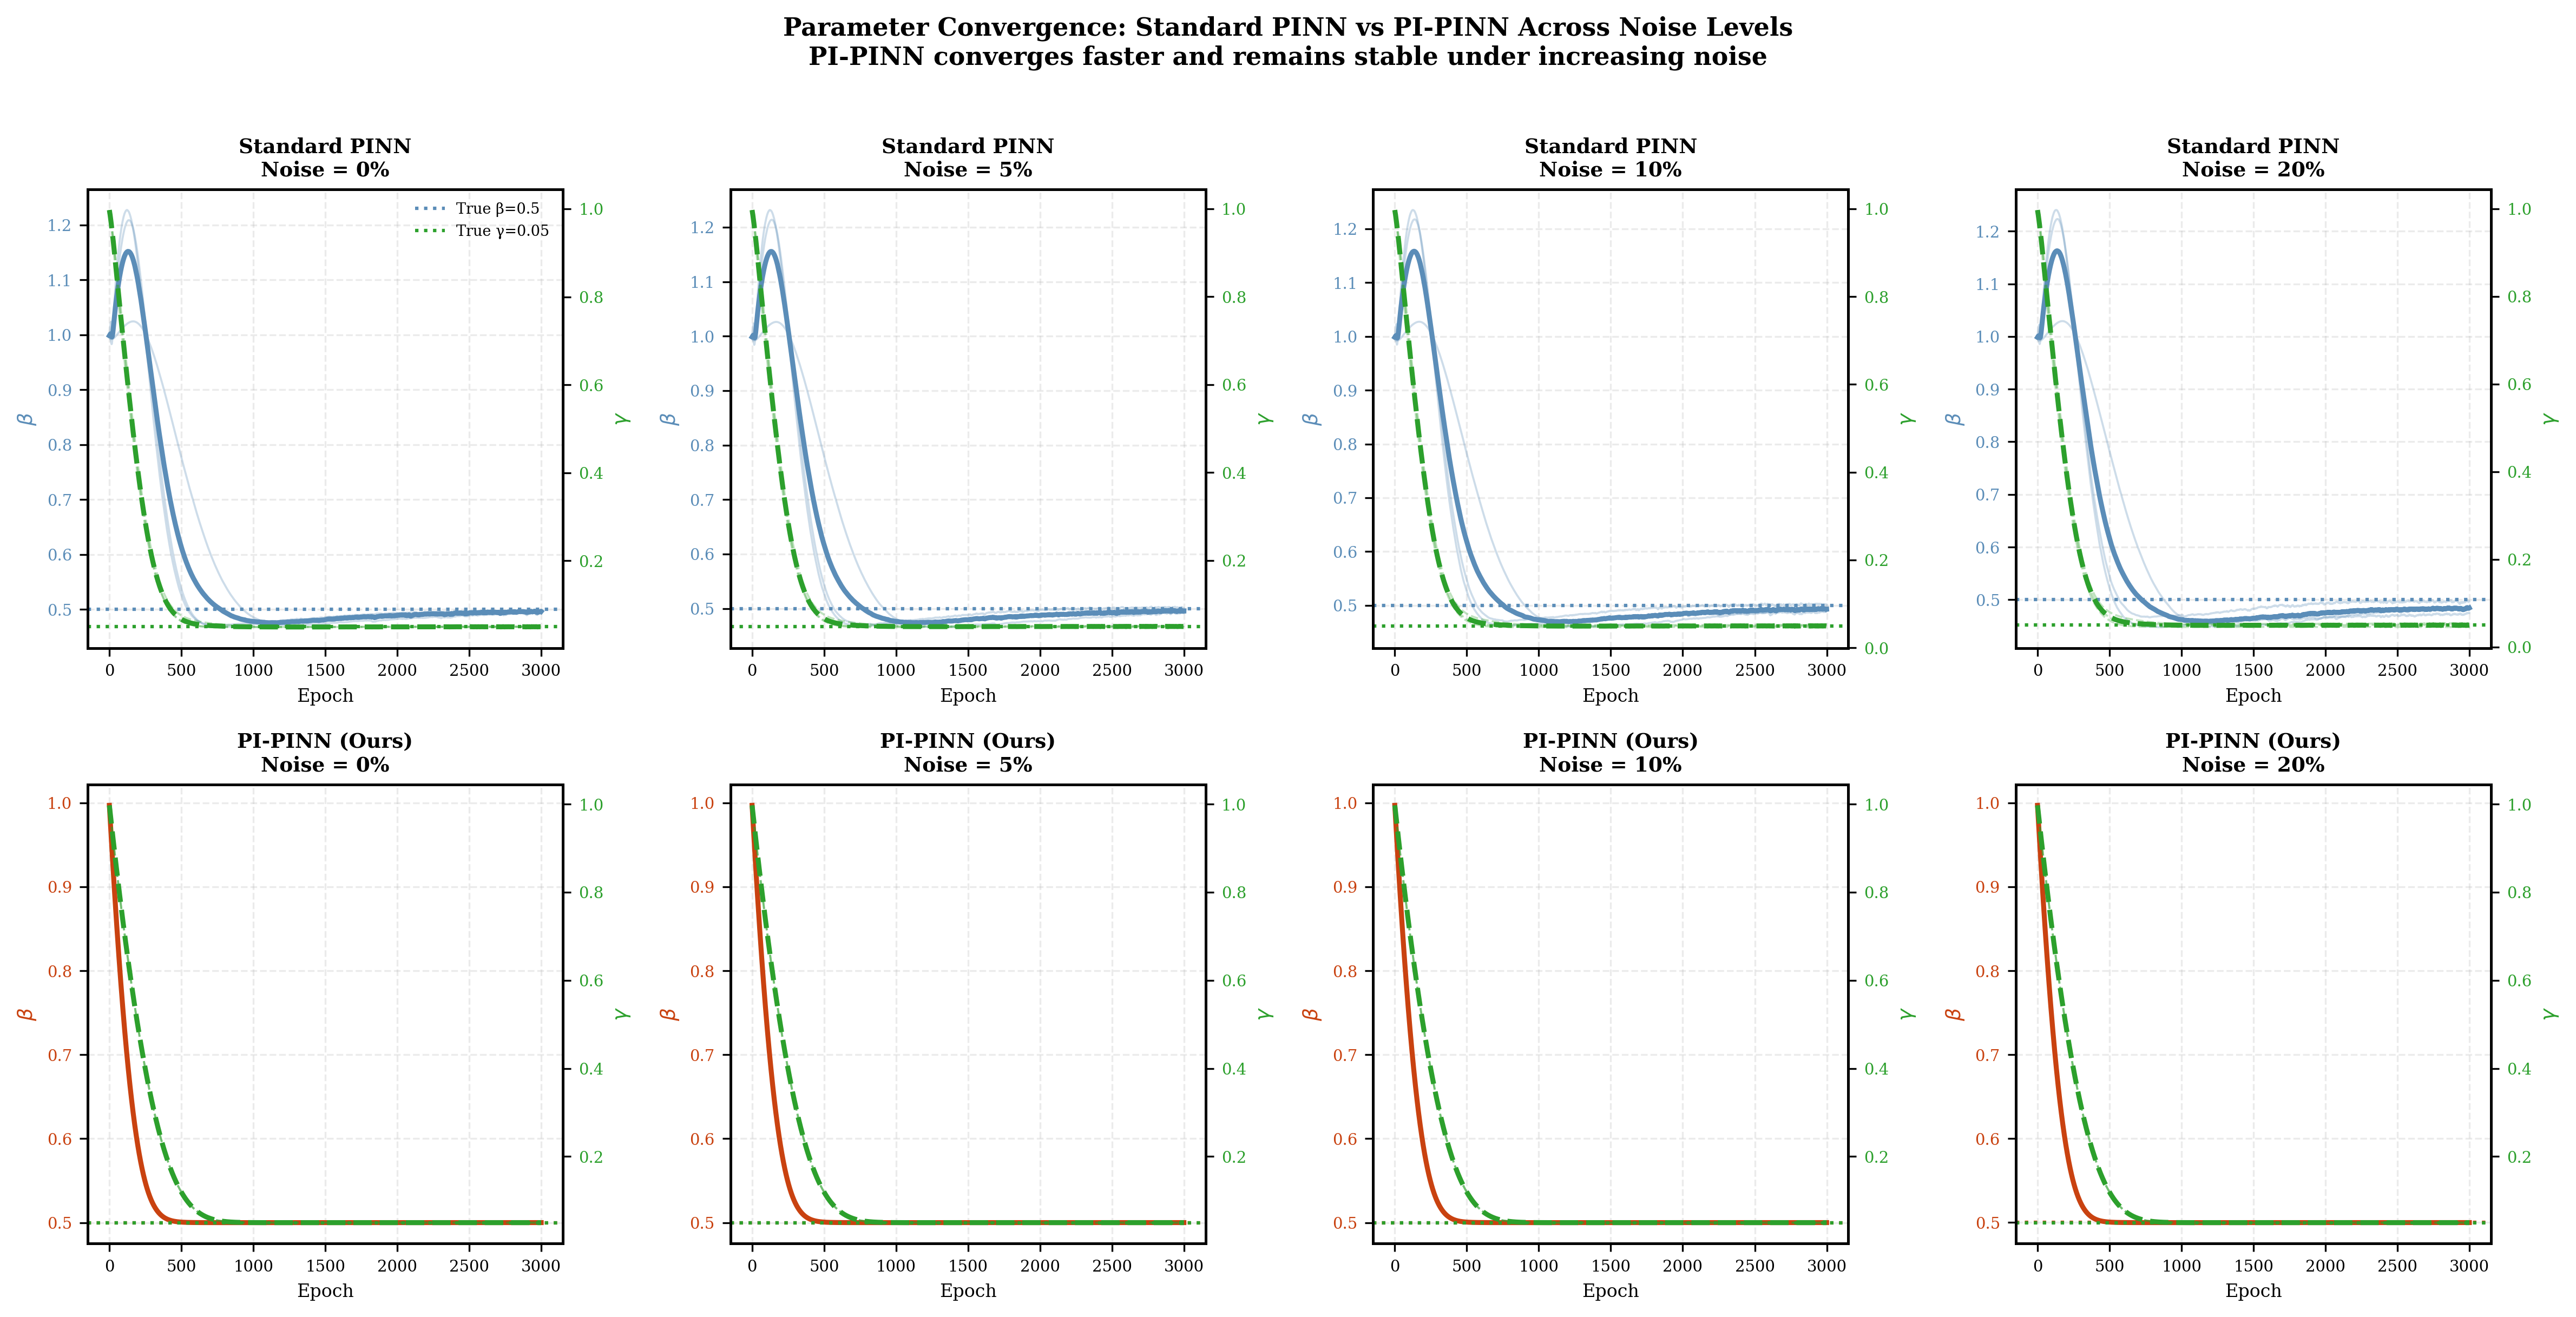

Saved: Fig_Noise_Convergence_Panel.png


In [17]:
# ══════════════════════════════════════════════════════════════════
# 2 rows (PINN, PI-PINN) × 4 columns (0%, 5%, 10%, 20%)
# Each panel: beta convergence traces across 3 seeds
# Shows: PI-PINN converges faster and more stably
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=300)

for col, r in enumerate(noise_results):
    for row, (traces, model_name, color) in enumerate([
            (r['pinn_traces'],   'Standard PINN',  '#5b8db8'),
            (r['pipinn_traces'], 'PI-PINN (Ours)', '#c94210')
    ]):
        ax  = axes[row, col]
        ax2 = ax.twinx()

        for tr in traces:
            ep_b = np.arange(len(tr['beta']))
            ep_g = np.arange(len(tr['gamma']))
            ax.plot(ep_b,  tr['beta'],  color=color,    alpha=0.3, linewidth=0.9)
            ax2.plot(ep_g, tr['gamma'], color='#2ca02c', alpha=0.3,
                     linewidth=0.9, linestyle='--')

        # Mean traces
        min_b = min(len(tr['beta'])  for tr in traces)
        min_g = min(len(tr['gamma']) for tr in traces)
        b_mat = np.array([tr['beta'][:min_b]  for tr in traces])
        g_mat = np.array([tr['gamma'][:min_g] for tr in traces])

        ax.plot(np.arange(min_b),  b_mat.mean(0), color=color,    linewidth=2.2)
        ax2.plot(np.arange(min_g), g_mat.mean(0), color='#2ca02c', linewidth=2.2,
                  linestyle='--')

        # True value lines
        ax.axhline(TRUE_PARAMS['beta'],  color=color,    linestyle=':',  linewidth=1.5,
                   label=f'True β={TRUE_PARAMS["beta"]}')
        ax2.axhline(TRUE_PARAMS['gamma'], color='#2ca02c', linestyle=':',  linewidth=1.5,
                    label=f'True γ={TRUE_PARAMS["gamma"]}')

        ax.set_title(f'{model_name}\nNoise = {r["noise_pct"]}%',
                      fontsize=9, fontweight='bold', pad=6)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel(r'$\beta$', color=color, fontsize=9)
        ax2.set_ylabel(r'$\gamma$', color='#2ca02c', fontsize=9)
        ax.tick_params(axis='y', labelcolor=color, labelsize=7)
        ax2.tick_params(axis='y', labelcolor='#2ca02c', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='--', alpha=0.25)
        ax.tick_params(axis='x', labelsize=7)

        if row == 0 and col == 0:
            l1, lb1 = ax.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            ax.legend(l1+l2, lb1+lb2, loc='upper right',
                       frameon=False, fontsize=6.5)

fig.suptitle(
    'Parameter Convergence: Standard PINN vs PI-PINN Across Noise Levels\n'
    'PI-PINN converges faster and remains stable under increasing noise',
    fontsize=11, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('Fig_Noise_Convergence_Panel.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Noise_Convergence_Panel.png')

## 10. Figure D — Test Predictions at 20% Noise (Worst Case Visualization)

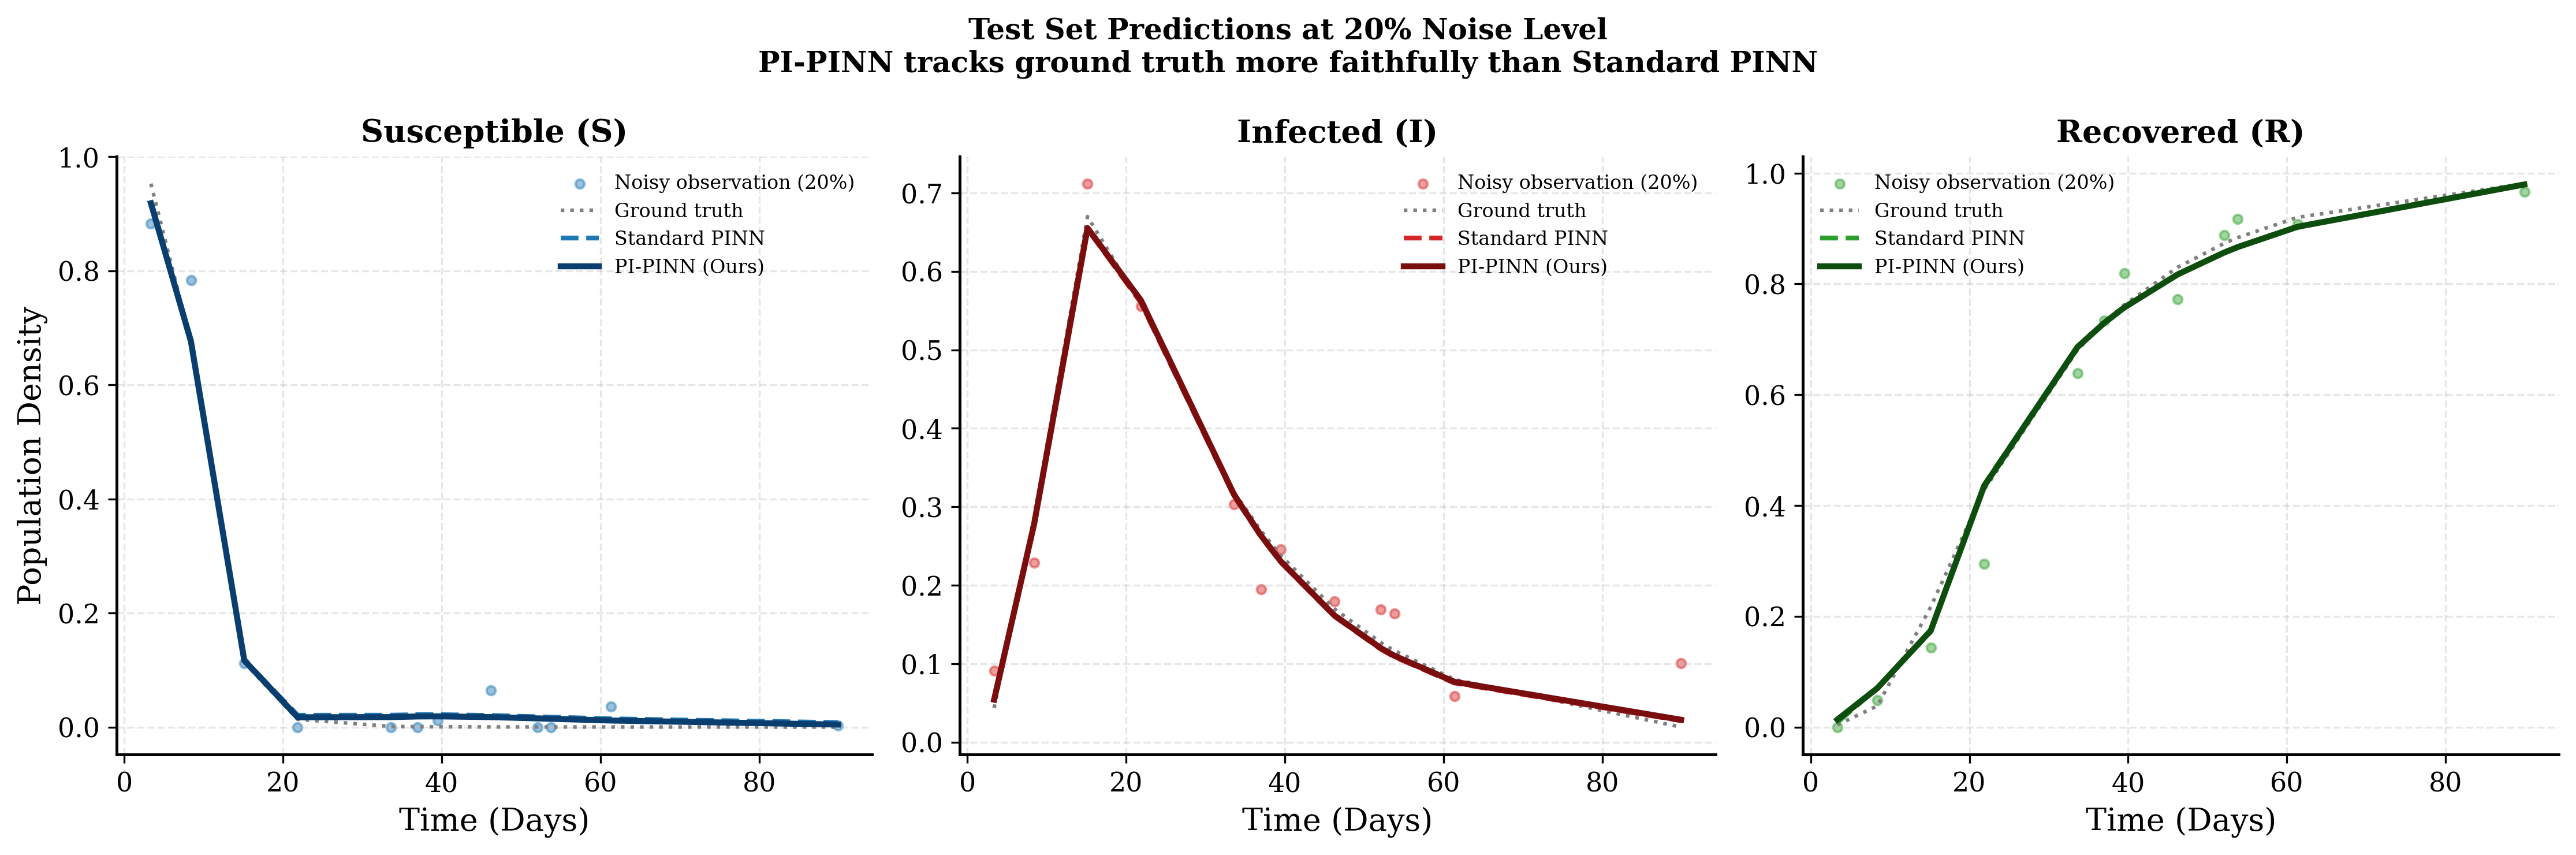

Saved: Fig_Noise_20pct_Predictions.png


In [18]:
# ══════════════════════════════════════════════════════════════════
# Retrain one model at 20% noise for visualization on test set
# This shows qualitative prediction quality under heavy noise
# ══════════════════════════════════════════════════════════════════

SEED_VIZ = 42
NOISE_VIZ = 0.20

rng_viz = np.random.default_rng(SEED_VIZ)
S_tr_v, I_tr_v, R_tr_v = add_gaussian_noise(
    S_train_clean, I_train_clean, R_train_clean, NOISE_VIZ, rng_viz)
S_vl_v, I_vl_v, R_vl_v = add_gaussian_noise(
    S_val_clean, I_val_clean, R_val_clean, NOISE_VIZ, rng_viz)

t_vl_v = to_tensor(t_val,   device)
S_vl_vt = to_tensor(S_vl_v, device)
I_vl_vt = to_tensor(I_vl_v, device)
R_vl_vt = to_tensor(R_vl_v, device)
t_te_v  = to_tensor(t_test, device)

# Standard PINN
torch.manual_seed(SEED_VIZ); np.random.seed(SEED_VIZ)
m_pinn_20, opt_pinn_20 = fresh_model_and_opt(SEED_VIZ)
ldr_p20 = make_loader(t_train, S_tr_v, I_tr_v, R_tr_v, BATCH_SIZE, device)
train_sir(m_pinn_20, opt_pinn_20, ldr_p20,
           t_vl_v, S_vl_vt, I_vl_vt, R_vl_vt,
           EPOCHS, use_prior=False, verbose=False)

# PI-PINN
torch.manual_seed(SEED_VIZ); np.random.seed(SEED_VIZ)
m_pi_20, opt_pi_20 = fresh_model_and_opt(SEED_VIZ)
ldr_pi20 = make_loader(t_train, S_tr_v, I_tr_v, R_tr_v, BATCH_SIZE, device)
train_sir(m_pi_20, opt_pi_20, ldr_pi20,
           t_vl_v, S_vl_vt, I_vl_vt, R_vl_vt,
           EPOCHS, use_prior=True, verbose=False)

# Test predictions
with torch.no_grad():
    out_p20  = m_pinn_20(t_te_v).cpu().numpy()
    out_pi20 = m_pi_20(t_te_v).cpu().numpy()

S_p20  = out_p20[:,0];  I_p20  = out_p20[:,1];  R_p20  = out_p20[:,2]
S_pi20 = out_pi20[:,0]; I_pi20 = out_pi20[:,1]; R_pi20 = out_pi20[:,2]

S_te   = S_test.ravel(); I_te = I_test.ravel(); R_te = R_test.ravel()
t_te   = t_test.ravel()

# Add noisy observations for visual reference
rng_v2 = np.random.default_rng(SEED_VIZ + 99)
S_te_n, I_te_n, R_te_n = add_gaussian_noise(
    S_test, I_test, R_test, NOISE_VIZ, rng_v2)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
C = [('#1f77b4','#0a3e6e'),
     ('#d62728','#7a0d0d'),
     ('#2ca02c','#0d4d0d')]
compartments = [
    ('Susceptible (S)', S_te, S_te_n.ravel(), S_p20, S_pi20),
    ('Infected (I)',    I_te, I_te_n.ravel(), I_p20, I_pi20),
    ('Recovered (R)',   R_te, R_te_n.ravel(), R_p20, R_pi20),
]

for idx, (title, clean, noisy_obs, pinn_pred, pi_pred) in enumerate(compartments):
    ax = axes[idx]
    light, dark = C[idx]

    ax.scatter(t_te, noisy_obs, s=14, alpha=0.45, color=light, label='Noisy observation (20%)')
    ax.plot(t_te, clean,     color='gray', linewidth=1.5, linestyle=':', label='Ground truth')
    ax.plot(t_te, pinn_pred, color=light,  linewidth=2.0, linestyle='--', label='Standard PINN')
    ax.plot(t_te, pi_pred,   color=dark,   linewidth=2.5, linestyle='-',  label='PI-PINN (Ours)')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Population Density' if idx == 0 else '')
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)

fig.suptitle(
    'Test Set Predictions at 20% Noise Level\n'
    'PI-PINN tracks ground truth more faithfully than Standard PINN',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_Noise_20pct_Predictions.png', dpi=500, bbox_inches='tight')
plt.show()
print('Saved: Fig_Noise_20pct_Predictions.png')